In [5]:
import os, pickle

import sys
sys.path.insert(1, '..')

from physics.simulation import msq, mcfm
from physics.hzz import zpair, zz4l
from datasets import jointlikelihood
from models import alice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
from sklearn.preprocessing import StandardScaler
import hist

import torch
from lightning import Trainer

In [6]:
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'


OUTPUT_DIR_1 = '../jobs/alice/refactor-four-SBI-vs-SIG'
OUTPUT_DIR_2 = '../jobs/alice/refactor-four-BKG-vs-SIG'

SAMPLE_DIR = '../..'

CHECKPOINT_1 = f'checkpoint-alice-epoch=54-val_loss=0.41.ckpt'
CHECKPOINT_2 = f'checkpoint-alice-epoch=51-val_loss=0.41.ckpt'

NUMERATOR_1, DENOMINATOR_1 = msq.Component.SBI, msq.Component.SIG
NUMERATOR_2, DENOMINATOR_2 = msq.Component.BKG, msq.Component.SIG

COMPONENT_FILE = msq.Component.SBI

SAMPLE_SIZE = 100000

FEATURES=['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

BATCH_SIZE = 256
SEED = 42

In [7]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

comp_strings = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.BKG : 'BKG',
    msq.Component.INT : 'INT'
}

In [8]:
events_1 = mcfm.from_csv(cross_section=xs[COMPONENT_FILE], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE]), n_rows=int(1.2*SAMPLE_SIZE)).reweight(COMPONENT_FILE, NUMERATOR_1)

z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

events_processed_1 = events_1.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]
events_processed_2 = events_processed_1.reweight(NUMERATOR_1, NUMERATOR_2)[:SAMPLE_SIZE]

0.6458769410846456


In [9]:
data_X_1 = events_processed_1.kinematics[FEATURES].to_numpy()
data_r_1 = events_processed_1.reweight(numerator=NUMERATOR_1, denominator=DENOMINATOR_1).probabilities/events_processed_1.probabilities
data_s_1 = (data_r_1/(1 + data_r_1)).to_numpy()

data_X_2 = events_processed_2.kinematics[FEATURES].to_numpy()
data_r_2 = events_processed_2.reweight(numerator=NUMERATOR_2, denominator=DENOMINATOR_2).probabilities/events_processed_2.probabilities
data_s_2 = (data_r_2/(1 + data_r_2)).to_numpy()


with open(os.path.join(OUTPUT_DIR_1, SCALER_FILE), 'rb') as f:
    scaler_1 = pickle.load(f)
    data_X_1 = scaler_1.transform(data_X_1)

with open(os.path.join(OUTPUT_DIR_2, SCALER_FILE), 'rb') as f:
    scaler_2 = pickle.load(f)
    data_X_2 = scaler_2.transform(data_X_2)

In [10]:
model_1 = alice.ALICE.load_from_checkpoint(os.path.join(OUTPUT_DIR_1, CHECKPOINT_DIR, CHECKPOINT_1))
predictions_1 = model_1(torch.tensor(data_X_1, dtype=torch.float32)).detach().view(-1).numpy()

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:758: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [11]:
model_2 = alice.ALICE.load_from_checkpoint(os.path.join(OUTPUT_DIR_2, CHECKPOINT_DIR, CHECKPOINT_2))
predictions_2 = model_2(torch.tensor(data_X_2, dtype=torch.float32)).detach().view(-1).numpy()

In [12]:
ratios_1 = predictions_1/(1-predictions_1)
ratios_2 = predictions_2/(1-predictions_2)

In [ ]:
ratios = ratios_1/ratios_2
ratios_labels = data_r_1.to_numpy()/data_r_2.to_numpy()

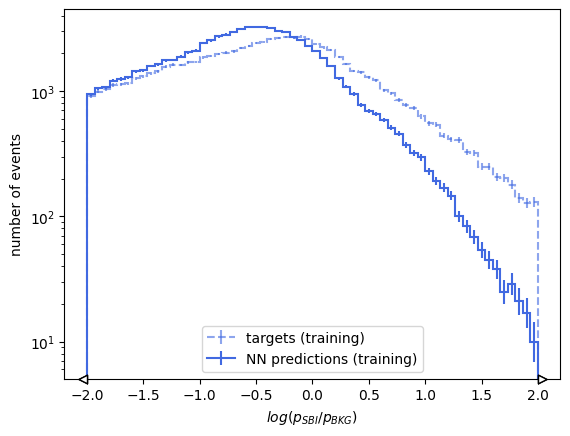

In [28]:
BINS = 60

bounds = [-2,2]

h_predictions = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions.fill(np.log(ratios/7))

h_targets = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets.fill(np.log(ratios_labels))

h_targets.plot(color='royalblue', linestyle='--', label='targets (training)', alpha=0.6)
h_predictions.plot(color='royalblue', linestyle='-', label='NN predictions (training)')

plt.xlabel(f'$log(p_{{{comp_strings[NUMERATOR_1]}}}/p_{{{comp_strings[NUMERATOR_2]}}})$')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

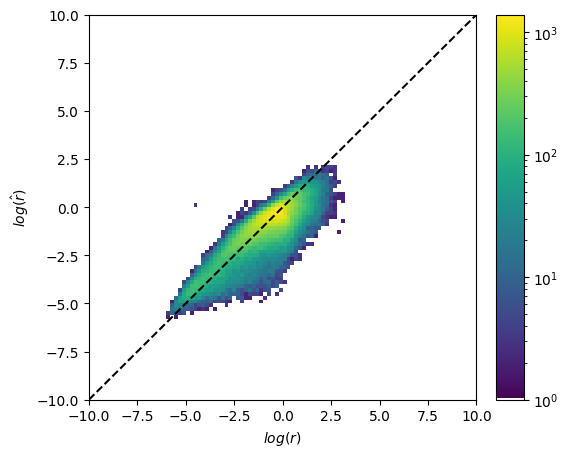

In [29]:
BINS=100

bounds = [-10,10]

h_calibration_val = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='$log(r)$'),
    hist.axis.Regular(BINS, *bounds, name='$log(\hat{r})$')
)

h_calibration_val.fill(np.log(ratios_labels), np.log(ratios/7))

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_val.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

plt.show()